In [1]:
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D
import time
from tqdm import tqdm
import pandas as pd
import numpy as np
import random
import torch
from scipy.ndimage import binary_erosion
from PIL import Image

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 1. Projector

In [3]:
class MatrixXRayProjector:
    def __init__(self, volume_shape, image_shape, pixel_spacing, SOD, SID):
        self.volume_shape = volume_shape
        self.image_shape = image_shape
        self.pixel_spacing = torch.tensor(pixel_spacing, device=device)
        self.SOD = SOD
        self.SID = SID
        
        # Create voxel coordinates grid (Z,Y,X)
        z, y, x = torch.meshgrid(
            torch.arange(volume_shape[0], device=device),
            torch.arange(volume_shape[1], device=device),
            torch.arange(volume_shape[2], device=device),
            indexing='ij'
        )
        # Convert to physical coordinates (mm) centered at isocenter
        self.voxel_coords = torch.stack((x, y, z), dim=-1).float()
        self.voxel_coords[..., 0] -= volume_shape[2] // 2  # X
        self.voxel_coords[..., 1] -= volume_shape[1] // 2  # Y
        self.voxel_coords[..., 2] -= volume_shape[0] // 2  # Z
        
    def get_rotation_matrix(self, alpha, beta):
        """Create rotation matrix as defined in the paper (equation 1)"""
        cos_a, sin_a = math.cos(alpha), math.sin(alpha)
        cos_b, sin_b = math.cos(beta), math.sin(beta)
        return torch.tensor([
            [cos_b,         sin_b*sin_a,      sin_b*cos_a],
            [0,             cos_a,            -sin_a],
            [-sin_b,        cos_b*sin_a,      cos_b*cos_a]
        ], device=device)
    
    def build_projection_matrix(self, alpha, beta):
        h, w = self.image_shape
        m, n, p = self.volume_shape
        total_pixels = h * w
        total_voxels = m * n * p
        
        row_indices = []
        col_indices = []
        
        R = self.get_rotation_matrix(alpha, beta)
        
        # Apply rotation to all voxels
        rotated_coords = torch.matmul(self.voxel_coords, R.T)
        
        # Translate to X-ray source coordinate system
        # Z-coordinate: distance from source to point
        proj_coords = rotated_coords.clone()
        proj_coords[..., 2] += self.SOD  # Add SOD to z-coordinate
        
        # Only consider points in front of the detector (z > 0)
        valid_mask = proj_coords[..., 2] > 0
        valid_voxels = torch.nonzero(valid_mask)
        
        if len(valid_voxels) == 0:
            return torch.sparse_coo_tensor(torch.empty((2, 0), dtype=torch.long), 
                                         torch.empty((0,)), 
                                         size=(total_pixels, total_voxels),
                                         device=device)
        
        # Perspective projection (equation 3)
        det_coords = (proj_coords[valid_mask][..., :2] / 
                     proj_coords[valid_mask][..., 2].unsqueeze(-1)) * self.SID
        
        # Convert to pixel coordinates
        pixel_coords = det_coords / self.pixel_spacing + torch.tensor([w/2, h/2], device=device)
        pixel_coords = pixel_coords.round().long()
        
        # Filter out-of-bound pixels
        pixel_valid = (
            (pixel_coords[:, 0] >= 0) & 
            (pixel_coords[:, 0] < w) & 
            (pixel_coords[:, 1] >= 0) & 
            (pixel_coords[:, 1] < h))
        
        if torch.sum(pixel_valid) == 0:
            return torch.sparse_coo_tensor(torch.empty((2, 0), dtype=torch.long), 
                                         torch.empty((0,)), 
                                         size=(total_pixels, total_voxels),
                                         device=device)
        
        valid_pixel_coords = pixel_coords[pixel_valid]
        valid_voxel_indices = valid_voxels[pixel_valid]
        
        # Convert voxel indices to linear indices
        voxel_linear_indices = (
            valid_voxel_indices[:, 0] * n * p + 
            valid_voxel_indices[:, 1] * p + 
            valid_voxel_indices[:, 2])
        
        # Convert pixel coordinates to linear indices
        pixel_linear_indices = (
            valid_pixel_coords[:, 1] * w + 
            valid_pixel_coords[:, 0])
        
        # Create sparse matrix
        indices = torch.stack([pixel_linear_indices, voxel_linear_indices], dim=0)
        values = torch.ones(len(pixel_linear_indices), device=device)
        
        P = torch.sparse_coo_tensor(
            indices, 
            values, 
            size=(total_pixels, total_voxels),
            device=device
        )
        
        return P
    
    def project_volume(self, X, alpha, beta):
        P = self.build_projection_matrix(alpha, beta)
        if P._nnz() == 0:
            return torch.zeros(self.image_shape, device=device)
        
        vec_X = X.flatten().float()
        proj_vec = torch.sparse.mm(P, vec_X.unsqueeze(-1)).squeeze()
        proj_image = (proj_vec > 0).reshape(self.image_shape)
        return proj_image

### 2. Create test objects

In [7]:
def draw_line_3d(volume, p1, p2, radius):
    """Draw a cylinder-like line between p1 and p2 using bresenham approximation."""
    #随便定义俩点
    p1 = np.array(p1).astype(int)
    p2 = np.array(p2).astype(int)
    #俩点距离
    length = np.linalg.norm(p2 - p1)
    #把p1和p2之间根据长度切成好多等份（步长最小为1）
    steps = max(int(length * 2), 1)#length*a 保证足够连续，而非一个一个球粗糙连接在一起
    for i in range(steps + 1):
        t = i / steps
        point = (1 - t) * p1 + t * p2#线性插值
        z, y, x = point.astype(int)
        #在所有插值处绘制球体，实现圆柱体效果
        for dz in range(-radius, radius + 1):
            for dy in range(-radius, radius + 1):
                for dx in range(-radius, radius + 1):
                    if dz**2 + dy**2 + dx**2 <= radius**2:#dx，dy，dz这些增量必须满足球体方程
                        zz, yy, xx = z + dz, y + dy, x + dx
                        if 0 <= zz < volume.shape[0] and 0 <= yy < volume.shape[1] and 0 <= xx < volume.shape[2]:#边界check
                            volume[zz, yy, xx] = 1#标记为血管

def grow_branch(volume, p1, direction, length, radius, angle_range, depth, rng):
    """Recursively grow artery branches with controlled randomness."""
    if depth <= 0 or radius <= 0:
        return
    p2 = p1 + direction * length
    draw_line_3d(volume, p1, p2, radius)
    
    num_branches = rng.randint(1, 3)  # Now 1-2 branches (inclusive)
    for _ in range(num_branches):
        new_dir = direction + rng.uniform(-angle_range, angle_range, size=3)
        new_dir = new_dir / np.linalg.norm(new_dir)
        grow_branch(volume, p2, new_dir, 
                   length * rng.uniform(0.6, 0.9), 
                   max(1, radius - 1), 
                   angle_range, 
                   depth - 1,
                   rng)

def create_test_objects(volume_shape, tree_seed=142):
    volume = torch.zeros(volume_shape, device=device)
    center = torch.tensor(volume_shape) // 2
    
    # Coordinate grids (Z,Y,X)
    z, y, x = torch.meshgrid(
        torch.arange(volume_shape[0], device=device),
        torch.arange(volume_shape[1], device=device),
        torch.arange(volume_shape[2], device=device),
        indexing='ij'
    )

    # 1. Cube
    cube_size = 20
    half = cube_size // 2
    cube = volume.clone()
    cube[center[0]-half:center[0]+half,
         center[1]-half:center[1]+half,
         center[2]-half:center[2]+half] = 1

    # 2. Cylinder
    radius = 10
    length = 30
    cylinder = volume.clone()
    mask = ((y - center[1])**2 + (z - center[0])**2 <= radius**2) & \
           (x >= center[2]-length//2) & (x <= center[2]+length//2)
    cylinder[mask] = 1

    # 3. Star (cross)
    cross_width = 5
    cross_length = 25
    star = volume.clone()
    star[center[0]-cross_width//2:center[0]+cross_width//2,
         center[1]-cross_width//2:center[1]+cross_width//2,
         center[2]-cross_length//2:center[2]+cross_length//2] = 1
    star[center[0]-cross_width//2:center[0]+cross_width//2,
         center[1]-cross_length//2:center[1]+cross_length//2,
         center[2]-cross_width//2:center[2]+cross_width//2] = 1
    star[center[0]-cross_length//2:center[0]+cross_length//2,
         center[1]-cross_width//2:center[1]+cross_width//2,
         center[2]-cross_width//2:center[2]+cross_width//2] = 1

    # 4. Sphere
    sphere = volume.clone()
    sphere_radius = 15
    mask = ((x - center[2])**2 + (y - center[1])**2 + (z - center[0])**2) <= sphere_radius**2
    sphere[mask] = 1

    # 5. Torus
    torus = volume.clone()
    R = 15
    r = 5
    mask = (torch.sqrt((y - center[1])**2 + (z - center[0])**2) - R)**2 + (x - center[2])**2 <= r**2
    torus[mask] = 1

    # 6. Helix
    helix = volume.clone()
    helix_radius = 10
    turns = 2
    pitch = 30
    for t in torch.linspace(0, turns*2*np.pi, 100):
        x_pos = int(center[2] + helix_radius * math.cos(t))
        y_pos = int(center[1] + helix_radius * math.sin(t))
        z_pos = int(center[0] + pitch * t / (2*np.pi))
        if all(0 <= p < s for p, s in zip((z_pos, y_pos, x_pos), volume_shape)):
            helix[z_pos, y_pos, x_pos] = 1
        for dz, dy, dx in [(0,0,0), (0,0,1), (0,1,0), (1,0,0)]:
            nz, ny, nx = z_pos+dz, y_pos+dy, x_pos+dx
            if all(0 <= p < s for p, s in zip((nz, ny, nx), volume_shape)):
                helix[nz, ny, nx] = 1

    #7. Synthetic Coronary Tree
    coronary_np = np.zeros(volume_shape, dtype=np.uint8)
    rng = np.random.RandomState(tree_seed)  # Controlled random generator
    root = np.array([10, volume_shape[1] // 2, volume_shape[2] // 2])
    initial_dir = np.array([1.0, 0.0, 0.0])
    grow_branch(coronary_np, root, initial_dir, 12, 3, 0.5, 5, rng)
    coronary = torch.tensor(coronary_np, device=device)

    return {
        #'Cube': cube,
        #'Cylinder': cylinder,
        #'Star': star,
        #'Sphere': sphere,
        #'Torus': torus,
        #'Helix': helix,
        'CoronaryTree': coronary
    }

def plot_3d_voxels(voxels, title):
    """Visualize 3D voxels with consistent coordinate system"""
    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection='3d')
    
    coords = torch.nonzero(voxels).cpu().numpy()
    if len(coords) > 0:
        # Plot as (X, Z, Y) to match projection views
        ax.scatter(coords[:, 2], coords[:, 0], coords[:, 1],
                  color='blue', s=2, alpha=0.8, depthshade=True)
    
    ax.set_xlabel('X (Horizontal)')
    ax.set_ylabel('Z (Depth)')
    ax.set_zlabel('Y (Vertical)')
    ax.set_title(title, pad=10)
    ax.set_xlim(0, voxels.shape[2])
    ax.set_ylim(0, voxels.shape[0])
    ax.set_zlim(0, voxels.shape[1])
    ax.view_init(elev=20, azim=-45)  # Standard isometric view
    plt.tight_layout()
    plt.show()

def visualize_object_projections(obj_name, obj_volume, projector):
    """Visualize 3D object and its X-ray projections"""
    angles = [
        (0, 0),          # Front view
        (math.pi/6, 0),  # 30° X-rotation
        #(0, math.pi/6),  # 30° Y-rotation
        #(math.pi/6, math.pi/6)  # Combined rotation
    ]
    
    print(f"\nVisualizing {obj_name}...")
    
    # Combined visualization
    fig = plt.figure(figsize=(18, 4))
    fig.suptitle(f'{obj_name} - 3D View and Projections', y=1.05)
    
    # 3D View (subplot 1)
    ax_3d = fig.add_subplot(1, 5, 1, projection='3d')
    coords = torch.nonzero(obj_volume).cpu().numpy()
    if len(coords) > 0:
        ax_3d.scatter(coords[:, 2], coords[:, 0], coords[:, 1],
                     color='blue', s=2, alpha=0.8)
    ax_3d.set_title('3D View')
    ax_3d.set_xlim(0, obj_volume.shape[2])
    ax_3d.set_ylim(0, obj_volume.shape[0])
    ax_3d.set_zlim(0, obj_volume.shape[1])
    ax_3d.view_init(elev=20, azim=-45)
    
    # Projections (subplots 2-5)
    for i, (alpha, beta) in enumerate(angles):
        ax = fig.add_subplot(1, 5, i+2)
        proj_image = projector.project_volume(obj_volume, alpha, beta)
        ax.imshow(proj_image.cpu().numpy(), cmap='gray')
        ax.set_title(f'α={math.degrees(alpha):.0f}° β={math.degrees(beta):.0f}°')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

In [8]:
def calculate_voxel_spacing(obj_volume, SOD, SID, pixel_spacing, angles):
    """Calculate required voxel spacing based on theory in Section 3.1"""
    EPS = 1e-8
    
    # Get non-zero voxel coordinates
    non_zero_coords = torch.nonzero(obj_volume).float()
    if len(non_zero_coords) == 0:
        return (0, 0, 0), (0, 0, 0)
    
    # Center coordinates at isocenter
    center = torch.tensor(obj_volume.shape) // 2
    phys_coords = non_zero_coords.clone()
    phys_coords[:, 0] -= center[0]  # Z
    phys_coords[:, 1] -= center[1]  # Y
    phys_coords[:, 2] -= center[2]  # X
    
    # Downsample if too many points
    if len(phys_coords) > 10000:
        idx = torch.randperm(len(phys_coords))[:10000]
        phys_coords = phys_coords[idx]
    
    # Physical dimensions (mm)
    w_x = (phys_coords[:, 2].max() - phys_coords[:, 2].min()).item()
    w_y = (phys_coords[:, 1].max() - phys_coords[:, 1].min()).item()
    w_z = (phys_coords[:, 0].max() - phys_coords[:, 0].min()).item()
    
    # Initialize bounds
    d_x_bound = float('inf')
    d_y_bound = float('inf')
    d_z_bound = float('inf')
    
    for alpha, beta in angles:
        cos_a = math.cos(alpha)
        sin_a = math.sin(alpha)
        cos_b = math.cos(beta)
        sin_b = math.sin(beta)
        
        # Rotation matrices
        Rx = torch.tensor([
            [1, 0, 0],
            [0, cos_a, -sin_a],
            [0, sin_a, cos_a]
        ], device=device)
        
        Ry = torch.tensor([
            [cos_b, 0, sin_b],
            [0, 1, 0],
            [-sin_b, 0, cos_b]
        ], device=device)
        
        # Rotate coordinates
        rotated_coords = torch.matmul(Ry, torch.matmul(Rx, phys_coords.T)).T
        
        # Translate to source coordinate system
        z_prime = rotated_coords[:, 2] + SOD
        
        # Find min z_prime for this angle
        min_z_prime = z_prime.min().item()
        
        # Avoid division by zero
        min_z_prime = max(min_z_prime, 1.0)
        
        # Calculate bounds for this angle (equations 9 and 11)
        d_x_ang = (pixel_spacing[0] * min_z_prime) / (abs(cos_b) * SID + EPS)
        d_y_ang1 = (pixel_spacing[0] * min_z_prime) / (abs(sin_b * sin_a) * SID + EPS)
        d_y_ang2 = (pixel_spacing[1] * min_z_prime) / (abs(cos_a) * SID + EPS)
        d_y_ang = min(d_y_ang1, d_y_ang2)
        
        d_z_ang1 = (pixel_spacing[0] * min_z_prime) / (abs(sin_b * cos_a) * SID + EPS)
        d_z_ang2 = (pixel_spacing[1] * min_z_prime) / (abs(sin_a) * SID + EPS)
        d_z_ang = min(d_z_ang1, d_z_ang2)
        
        # Update global bounds
        d_x_bound = min(d_x_bound, d_x_ang)
        d_y_bound = min(d_y_bound, d_y_ang)
        d_z_bound = min(d_z_bound, d_z_ang)
    
    # Calculate resolution
    res_x = math.ceil(w_x / d_x_bound) if d_x_bound > 0 else 1
    res_y = math.ceil(w_y / d_y_bound) if d_y_bound > 0 else 1
    res_z = math.ceil(w_z / d_z_bound) if d_z_bound > 0 else 1
    
    return (d_x_bound, d_y_bound, d_z_bound), (res_x, res_y, res_z)


Processing CoronaryTree...

Visualizing CoronaryTree...


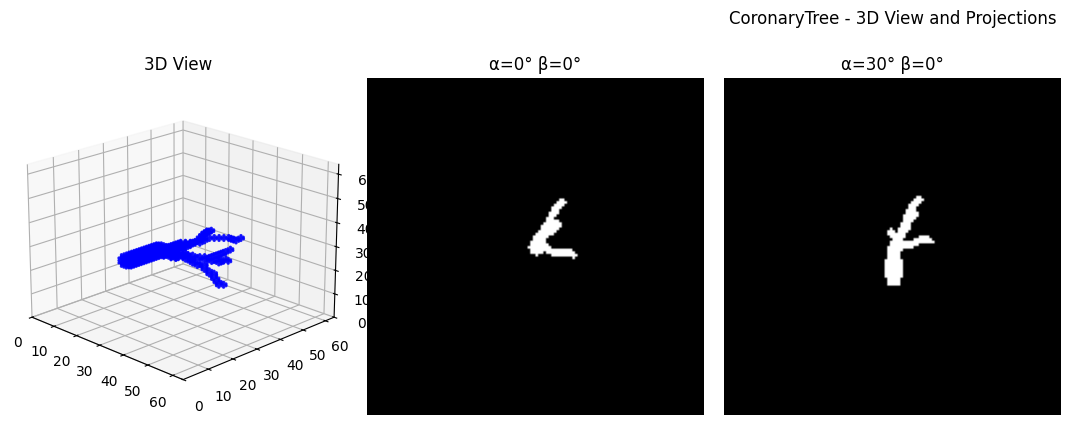

Calculated voxel spacing: dx=0.2485mm, dy=0.2485mm, dz=0.4971mm
Required resolution: 73 x 89 x 81


In [9]:
def main():
    # Initial parameters
    SOD = 500.0
    SID = 1000.0
    pixel_spacing = (0.5, 0.5)
    low_res_shape = (64, 64, 64)
    #angles = [(0, 0), (math.pi/6, 0), (0, math.pi/6), (math.pi/6, math.pi/6)]
    angles = [(0, 0), (math.pi/6, 0)]
    
    # Create projector with consistent 128x128 resolution
    projector = MatrixXRayProjector(low_res_shape, (128, 128), 
                                   (pixel_spacing[0]*4, pixel_spacing[1]*4), 
                                   SOD, SID)
    
    # Create all test objects in low resolution
    test_objects = create_test_objects(low_res_shape)
    
    # Process each object
    for obj_name, low_res_volume in test_objects.items():
        print(f"\nProcessing {obj_name}...")
        
        # Visualize low-resolution object
        visualize_object_projections(obj_name, low_res_volume, projector)
        
        # Calculate required resolution
        (d_x, d_y, d_z), (res_x, res_y, res_z) = calculate_voxel_spacing(
            low_res_volume, SOD, SID, pixel_spacing, angles
        )
        
        print(f"Calculated voxel spacing: dx={d_x:.4f}mm, dy={d_y:.4f}mm, dz={d_z:.4f}mm")
        print(f"Required resolution: {res_x} x {res_y} x {res_z}")
        
        # Limit resolution to avoid excessive memory usage
        res_x = min(res_x, 128)
        res_y = min(res_y, 128)
        res_z = min(res_z, 128)
        high_res_shape = (int(res_z), int(res_y), int(res_x))
        
        #print(f"Using practical resolution: {high_res_shape}")
        
        # Create high-resolution object
        high_res_objects = create_test_objects(high_res_shape)
        high_res_volume = high_res_objects.get(obj_name, 
                                              torch.zeros(high_res_shape, device=device))
        

if __name__ == "__main__":
    main()

### 3. Reconstruction

#### 3.1 Reconstruction Framework (including visualization for evaluation)

In [10]:
def reconstruct_from_projections(test_objects, projector, num_iterations=5000, lr=0.01):
    """Reconstruct 3D objects from their projections using optimization"""
    results = {}
    angles = [
        (0, 0),          # Front view
        (math.pi/6, 0),  # 30° X-rotation
        (0, math.pi/6),  # 30° Y-rotation
        (math.pi/6, math.pi/6)  # Combined rotation
    ]
    
    for obj_name, true_volume in test_objects.items():
        print(f"\nReconstructing {obj_name}...")
        
        # 1. Get the ground truth projections (I_k)
        projections = []
        projection_matrices = []
        for alpha, beta in angles:
            P = projector.build_projection_matrix(alpha, beta)
            I_k = projector.project_volume(true_volume, alpha, beta)
            projections.append(I_k)
            #print(I_k.float().max(),I_k.float().min())
            projection_matrices.append(P)

        #P = projection_matrices[0]
        #test_input = torch.ones(volume_shape).flatten().to(device)
        #output = torch.sparse.mm(P, test_input.unsqueeze(-1)).max()
        #print(f"全1输入时的最大投影值: {output.item()}")  # 如果>>1，说明需要归一化

        #P = projection_matrices[0]
        #print(f"Projection matrix max value: {P._values().max().item()}")
        #if P._values().max() > 1.0:
            #for P in projection_matrices:
                #P._values().div_(P._values().max())
        #print(f"Projection matrix min value: {P._values().min().item()}")
        #if P._values().min() > 1.0:
            #for P in projection_matrices:
                #P._values().div_(P._values().min())
        
        # 2. Initialize the reconstructed volume (relaxed to [0,1])
        X_recon = torch.rand(projector.volume_shape, device=device, requires_grad=True)
        
        # 3. Set up optimizer
        optimizer = torch.optim.Adam([X_recon], lr=lr)
        
        # 4. Optimization loop
        loss_history = []
        best_loss = float('inf')
        best_X = None
        
        for iteration in tqdm(range(num_iterations)):
            optimizer.zero_grad()
            
            # Compute all projections
            total_loss = 0
            vec_X = X_recon.flatten()
            
            for P, I_k in zip(projection_matrices, projections):
                # Compute P·vec(X)
                proj = torch.sparse.mm(P, vec_X.unsqueeze(-1)).squeeze()
                #proj = proj.reshape(I_k.shape)# 不加max operator（也就是可能存在很多值为1的cube投影到同一个pixel）
                proj = proj.clamp(max=1.0).reshape(I_k.shape)
                
                # Compute Frobenius norm squared
                loss = torch.norm(proj - I_k.float(), p='fro')**2
                total_loss += loss
            
            # Add regularization to encourage binary solutions
            # This helps push values toward 0 or 1
            #reg = torch.norm(X_recon * (1 - X_recon), p=1)  # Encourages values to be 0 or 1
            #total_loss += 5 * reg
            
            # Track best solution
            if total_loss.item() < best_loss:
                best_loss = total_loss.item()
                best_X = X_recon.detach().clone()
            
            loss_history.append(total_loss.item())
            
            # Backpropagate and update
            total_loss.backward()
            if iteration % 100 == 0:
                grad_norm = X_recon.grad.norm().item()
                print(f"Iter {iter}: Loss={total_loss.item():.2f}, Grad Norm={grad_norm:.4f}")
            optimizer.step()
            
            # Project back to [0,1] range
            with torch.no_grad():
                X_recon.data = torch.clamp(X_recon, 0, 1)

        print(total_loss)

def visualize_reconstruction_results(results):
    """Visualize true and reconstructed volumes"""
    for obj_name, data in results.items():
        fig = plt.figure(figsize=(12, 4))
        fig.suptitle(f'Reconstruction Results for {obj_name}', y=1.05)
        
        # True volume
        ax1 = fig.add_subplot(131, projection='3d')
        coords = torch.nonzero(data['true']).cpu().numpy()
        if len(coords) > 0:
            ax1.scatter(coords[:, 2], coords[:, 0], coords[:, 1],
                      color='blue', s=2, alpha=0.8)
        ax1.set_title('True Volume')
        ax1.set_xlim(0, data['true'].shape[2])
        ax1.set_ylim(0, data['true'].shape[0])
        ax1.set_zlim(0, data['true'].shape[1])
        ax1.view_init(elev=20, azim=-45)
        
        # Reconstructed volume (binary)
        ax2 = fig.add_subplot(132, projection='3d')
        coords = torch.nonzero(data['reconstructed']).cpu().numpy()
        if len(coords) > 0:
            ax2.scatter(coords[:, 2], coords[:, 0], coords[:, 1],
                       color='red', s=2, alpha=0.8)
        ax2.set_title('Reconstructed Volume')
        ax2.set_xlim(0, data['reconstructed'].shape[2])
        ax2.set_ylim(0, data['reconstructed'].shape[0])
        ax2.set_zlim(0, data['reconstructed'].shape[1])
        ax2.view_init(elev=20, azim=-45)
        
        # Loss curve
        ax3 = fig.add_subplot(133)
        ax3.plot(data['loss_history'])
        ax3.set_title('Optimization Loss')
        ax3.set_xlabel('Iteration')
        ax3.set_ylabel('Loss')
        ax3.grid(True)
        
        plt.tight_layout()
        plt.show()

#### 3.2 Some necessary regular test before reconstruction


Testing with Ground Truth Initialization: CoronaryTree
Initial Loss (should be 0): 0.000000
Iter 0: Loss=0.000000, Grad Norm=0.000000
Iter 10: Loss=0.000000, Grad Norm=0.000000
Iter 20: Loss=0.000000, Grad Norm=0.000000
Iter 30: Loss=0.000000, Grad Norm=0.000000
Iter 40: Loss=0.000000, Grad Norm=0.000000
Iter 50: Loss=0.000000, Grad Norm=0.000000
Iter 60: Loss=0.000000, Grad Norm=0.000000
Iter 70: Loss=0.000000, Grad Norm=0.000000
Iter 80: Loss=0.000000, Grad Norm=0.000000
Iter 90: Loss=0.000000, Grad Norm=0.000000
Final Difference from Ground Truth: 0.000000


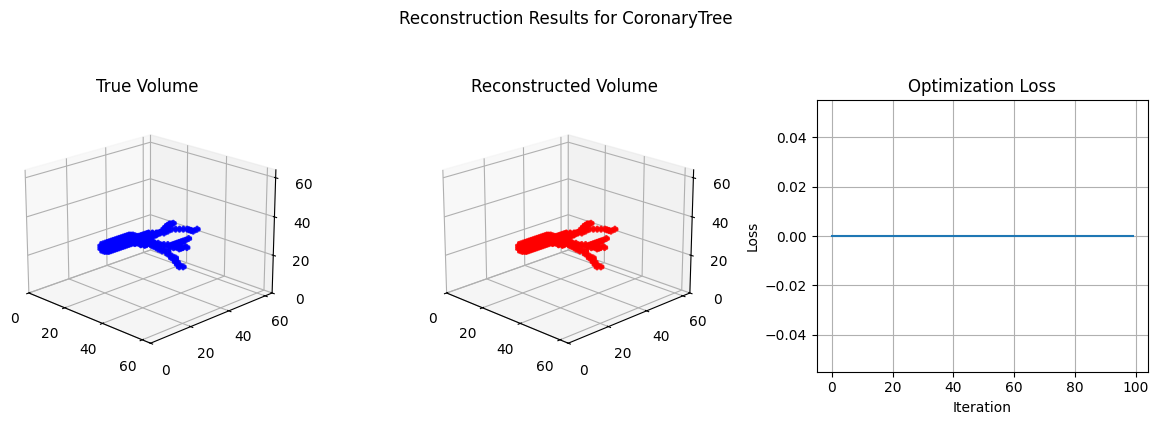

In [11]:
def reconstruct_with_ground_truth_init(test_objects, projector, num_iterations=100, lr=0.001):
    """使用ground truth作为initialization进行验证性优化，如果优化loss为0则优化过程没问题"""
    results = {}
    angles = [(0,0), (math.pi/6,0), (0,math.pi/6), (math.pi/6,math.pi/6)]
    
    for obj_name, true_volume in test_objects.items():
        print(f"\nTesting with Ground Truth Initialization: {obj_name}")
        
        # 1. projection data:
        projections = []
        projection_matrices = []
        for alpha, beta in angles:
            P = projector.build_projection_matrix(alpha, beta)
            I_k = projector.project_volume(true_volume, alpha, beta)
            projections.append(I_k)
            projection_matrices.append(P)

        # 2. use ground truth as initialization:
        X_recon = true_volume.clone().float().requires_grad_(True)
        
        # 3. optimizer:
        optimizer = torch.optim.Adam([X_recon], lr=lr)
        loss_history = []

        # 4. optimization:
        for iteration in range(num_iterations):
            optimizer.zero_grad()
            
            # loss calculation:
            total_loss = 0
            vec_X = X_recon.flatten()
            for P, I_k in zip(projection_matrices, projections):
                proj = torch.sparse.mm(P, vec_X.unsqueeze(-1)).squeeze()
                proj = proj.clamp(max=1.0).reshape(I_k.shape)
                loss = torch.norm(proj - I_k.float(), p='fro')**2
                total_loss += loss
            
            # print loss
            if iteration == 0:
                print(f"Initial Loss (should be 0): {total_loss.item():.6f}")
            
            loss_history.append(total_loss.item())
            
            total_loss.backward()
            optimizer.step()
            
            # print gradient norm
            if iteration % 10 == 0:
                grad_norm = X_recon.grad.norm().item() if X_recon.grad is not None else 0.0
                print(f"Iter {iteration}: Loss={total_loss.item():.6f}, Grad Norm={grad_norm:.6f}")

        # 5. final result:
        diff = torch.norm(X_recon - true_volume).item()
        print(f"Final Difference from Ground Truth: {diff:.6f}")
        
        # store results:
        results[obj_name] = {
            'true': true_volume,
            'reconstructed': X_recon.detach(),
            'loss_history': loss_history
        }
    
    return results

if __name__ == "__main__":
    volume_shape = (64, 64, 64)
    projector = MatrixXRayProjector(volume_shape, (512, 512), (0.5, 0.5), 500.0, 1000.0)
    test_objects = create_test_objects(volume_shape)
    
    # use GT for validation
    reconstruction_results = reconstruct_with_ground_truth_init(test_objects, projector)
    
    # visualization (GT = reconstruction)
    visualize_reconstruction_results(reconstruction_results)
    

In [12]:
def validate_ground_truth_loss(test_objects, projector):#检验是否ground truth的loss等于0
    """validate loss of ground truth equal to 0"""
    angles = [(0,0), (math.pi/6,0), (0,math.pi/6), (math.pi/6,math.pi/6)]
    
    for obj_name, true_volume in test_objects.items():
        print(f"\nValidating {obj_name}...")
        total_loss = 0
        
        # 计算ground truth的loss
        for alpha, beta in angles:
            P = projector.build_projection_matrix(alpha, beta)
            I_k = projector.project_volume(true_volume, alpha, beta)

            true_volume_float = true_volume.float()  # 转换为FloatTensor
            true_volume_flat = true_volume_float.flatten().unsqueeze(-1)
            
            # 计算P·vec(X_blue)
            proj = torch.sparse.mm(P, true_volume_flat).squeeze()
            proj = proj.reshape(I_k.shape).clamp(max=1.0)  # 与重建时一致
            
            loss = torch.norm(proj - I_k.float(), p='fro')**2
            total_loss += loss
            print(f"View ({alpha:.2f}, {beta:.2f}) Loss: {loss.item():.2f}")
        
        print(f"Total Loss for {obj_name}: {total_loss.item():.2f} (should be 0)")

if __name__ == "__main__":
    volume_shape = (64, 64, 64)
    projector = MatrixXRayProjector(volume_shape, (512, 512), (0.5, 0.5), 500.0, 1000.0)
    test_objects = create_test_objects(volume_shape)
    
    # validate ground truth
    validate_ground_truth_loss(test_objects, projector)


Validating CoronaryTree...
View (0.00, 0.00) Loss: 0.00
View (0.52, 0.00) Loss: 0.00
View (0.00, 0.52) Loss: 0.00
View (0.52, 0.52) Loss: 0.00
Total Loss for CoronaryTree: 0.00 (should be 0)


#### 3.3 Reconstruction process


Reconstructing CoronaryTree...


  0%|          | 9/8000 [00:00<03:11, 41.76it/s]

Iter <built-in function iter>: Loss=2436.00, Grad Norm=413.2941


  1%|▏         | 110/8000 [00:02<02:39, 49.38it/s]

Iter <built-in function iter>: Loss=1364.88, Grad Norm=137.6407


...

Iter <built-in function iter>: Loss=0.00, Grad Norm=0.0000


 99%|█████████▉| 7909/8000 [02:45<00:02, 44.34it/s]

Iter <built-in function iter>: Loss=0.00, Grad Norm=0.0000


100%|██████████| 8000/8000 [02:47<00:00, 47.88it/s]


tensor(0., device='cuda:0', grad_fn=<AddBackward0>)


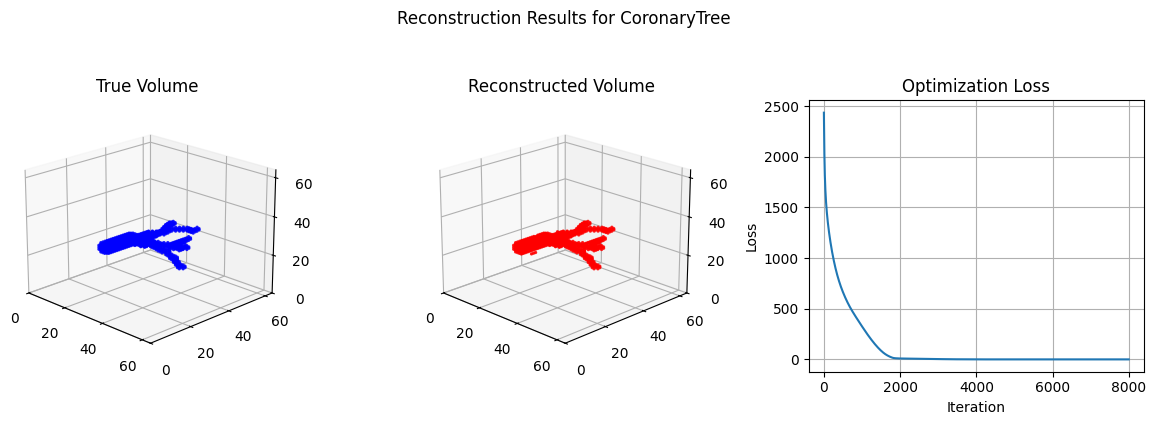

In [13]:
def reconstruct_from_projections(test_objects, projector, num_iterations=8000, lr=0.001):
    """Reconstruct 3D objects from their projections using optimization"""
    results = {}
    angles = [
        (0, 0),          # Front view
        (math.pi/6, 0),  # 30° X-rotation
        (0, math.pi/6),  # 30° Y-rotation
        (math.pi/6, math.pi/6)  # Combined rotation
    ]
    
    for obj_name, true_volume in test_objects.items():
        print(f"\nReconstructing {obj_name}...")
        
        # 1. Get the ground truth projections (I_k)
        projections = []
        projection_matrices = []
        for alpha, beta in angles:
            P = projector.build_projection_matrix(alpha, beta)
            I_k = projector.project_volume(true_volume, alpha, beta)
            projections.append(I_k)
            #print(I_k.float().max(),I_k.float().min())
            projection_matrices.append(P)

        #P = projection_matrices[0]
        #test_input = torch.ones(volume_shape).flatten().to(device)
        #output = torch.sparse.mm(P, test_input.unsqueeze(-1)).max()
        #print(f"全1输入时的最大投影值: {output.item()}")  # 如果>>1，说明需要归一化

        #P = projection_matrices[0]
        #print(f"Projection matrix max value: {P._values().max().item()}")
        #if P._values().max() > 1.0:
            #for P in projection_matrices:
                #P._values().div_(P._values().max())
        #print(f"Projection matrix min value: {P._values().min().item()}")
        #if P._values().min() > 1.0:
            #for P in projection_matrices:
                #P._values().div_(P._values().min())
        
        # 2. Initialize the reconstructed volume (relaxed to [0,1])
        #X_recon = torch.rand(projector.volume_shape, device=device, requires_grad=True)
        X_recon = torch.zeros(projector.volume_shape, device=device, requires_grad=True)
        
        # 3. Set up optimizer
        optimizer = torch.optim.Adam([X_recon], lr=lr)
        
        # 4. Optimization loop
        loss_history = []
        best_loss = float('inf')
        best_X = None
        
        for iteration in tqdm(range(num_iterations)):
            optimizer.zero_grad()
            
            # Compute all projections
            total_loss = 0
            vec_X = X_recon.flatten()
            
            for P, I_k in zip(projection_matrices, projections):
                # Compute P·vec(X)
                proj = torch.sparse.mm(P, vec_X.unsqueeze(-1)).squeeze()
                #proj = proj.reshape(I_k.shape)# 不加max operator（也就是可能存在很多值为1的cube投影到同一个pixel）
                proj = proj.clamp(max=1.0).reshape(I_k.shape)
                
                # Compute Frobenius norm squared
                loss = torch.norm(proj - I_k.float(), p='fro')**2
                total_loss += loss
            
            # Add regularization to encourage binary solutions
            # This helps push values toward 0 or 1
            reg = torch.norm(X_recon * (1 - X_recon), p=1)  # Encourages values to be 0 or 1
            total_loss += 0.5 * reg
            
            # Track best solution
            if total_loss.item() < best_loss:
                best_loss = total_loss.item()
                best_X = X_recon.detach().clone()
            
            loss_history.append(total_loss.item())
            
            # Backpropagate and update
            total_loss.backward()
            if iteration % 100 == 0:
                grad_norm = X_recon.grad.norm().item()
                print(f"Iter {iter}: Loss={total_loss.item():.2f}, Grad Norm={grad_norm:.4f}")
            optimizer.step()
            
            # Project back to [0,1] range
            with torch.no_grad():
                X_recon.data = torch.clamp(X_recon, 0, 1)

        print(total_loss)
        
        # 5. Store results (use the best solution found during optimization)
        threshold = 0.5  # For converting back to binary
        binary_recon = (best_X > threshold).float()
        results[obj_name] = {
            'true': true_volume,
            'reconstructed': binary_recon,
            'relaxed': best_X,
            'loss_history': loss_history
        }
    
    return results

def visualize_reconstruction_results(results):
    """Visualize true and reconstructed volumes"""
    for obj_name, data in results.items():
        fig = plt.figure(figsize=(12, 4))
        fig.suptitle(f'Reconstruction Results for {obj_name}', y=1.05)
        
        # True volume
        ax1 = fig.add_subplot(131, projection='3d')
        coords = torch.nonzero(data['true']).cpu().numpy()
        if len(coords) > 0:
            ax1.scatter(coords[:, 2], coords[:, 0], coords[:, 1],
                      color='blue', s=2, alpha=0.8)
        ax1.set_title('True Volume')
        ax1.set_xlim(0, data['true'].shape[2])
        ax1.set_ylim(0, data['true'].shape[0])
        ax1.set_zlim(0, data['true'].shape[1])
        ax1.view_init(elev=20, azim=-45)
        
        # Reconstructed volume (binary)
        ax2 = fig.add_subplot(132, projection='3d')
        coords = torch.nonzero(data['reconstructed']).cpu().numpy()
        if len(coords) > 0:
            ax2.scatter(coords[:, 2], coords[:, 0], coords[:, 1],
                       color='red', s=2, alpha=0.8)
        ax2.set_title('Reconstructed Volume')
        ax2.set_xlim(0, data['reconstructed'].shape[2])
        ax2.set_ylim(0, data['reconstructed'].shape[0])
        ax2.set_zlim(0, data['reconstructed'].shape[1])
        ax2.view_init(elev=20, azim=-45)
        
        # Loss curve
        ax3 = fig.add_subplot(133)
        ax3.plot(data['loss_history'])
        ax3.set_title('Optimization Loss')
        ax3.set_xlabel('Iteration')
        ax3.set_ylabel('Loss')
        ax3.grid(True)
        
        plt.tight_layout()
        plt.show()

# Main execution
if __name__ == "__main__":
    volume_shape = (64, 64, 64)
    projector = MatrixXRayProjector(volume_shape, (512, 512), (0.5, 0.5), 500.0, 1000.0)
    test_objects = create_test_objects(volume_shape)
    
    # Then perform reconstruction
    reconstruction_results = reconstruct_from_projections(test_objects, projector)
    
    # Visualize reconstruction results
    visualize_reconstruction_results(reconstruction_results)